# Data Comparison

In [1]:
import os 
import numpy as np
import pandas as pd
from   adjustText import adjust_text

import matplotlib.pyplot as plt
from   matplotlib.ticker import FuncFormatter

In [2]:
notebook_path = os.getcwd()
repo_path     = os.path.abspath(os.path.join(notebook_path, ".."))
data_path     = os.path.join(repo_path, "data")
prep_path     = os.path.join(data_path, "PrepData")
pic_path      = os.path.join(repo_path, "writeup", "pictures")

In [3]:
ticker_path = os.path.join(data_path, "FXTickerGuide.xlsx")
df_ticker   = pd.read_excel(io = ticker_path, sheet_name = "TickerGuide")

In [4]:
RENAMER = {
    "lag_rtn"        : "Lagged",
    "px_rtn"         : "None",
    "perf_rtn"       : "Contemporaneous",
    "carry"          : "Carry",
    "future"         : "Future",
    "liquid_future"  : "Liquid",
    "illiquid_future": "Illiquid",
    "g10_carry"      : "G10 Carry",
    "em_carry"       : "EM Carry"}

FLOAT_FORMAT = lambda x: f"{x:.2f}"

# Getting Data

In [5]:
matched_regions = (df_ticker
    .dropna()
    [["country", "ticker"]]
    .groupby("country")
    .agg("count")
    .loc[lambda x: x.ticker > 1]
    .index
    .to_list())

In [6]:
df_tmp_ticker = (df_ticker
    .loc[lambda x: x.country.isin(matched_regions)]
    .assign(asset_type = lambda x: x.group.str.split("_").str[-1])
    [["ticker", "country", "asset_type"]]
    .rename(columns = {"ticker": "security"}))

In [7]:
path   = os.path.join(prep_path, "FXVolTargetedReturns.parquet")
df_rtn = (pd
    .read_parquet(path = path, engine = "pyarrow")
    .merge(right = df_tmp_ticker, how = "inner", on = ["security"]))

# Examining the Data's history

In [8]:
display(df_rtn
    .loc[lambda x: x.asset_type == "future"]
    [["security", "country", "date"]]
    .rename(columns = {"security": "ticker"})
    .merge(right = df_ticker, how = "inner", on = ["ticker", "country"])
    [["ticker", "name", "date", "group"]]
    .assign(date = lambda x: pd.to_datetime(x.date).dt.date)
    .groupby(["ticker", "name", "group"])
    ["date"]
    .agg(["min", "max"])
    .reset_index()
    .replace(RENAMER)
    .rename(columns = {
        "ticker": "Future",
        "name"  : "Name",
        "group" : "Liquidity",
        "min"   : "Start Date",
        "max"   : "End Date"})
    .set_index("Future"))

,Name,Liquidity,Start Date,End Date
Future,,,,
AD1 Curncy,Australian Dollar Future,Liquid,1987-01-14,2026-01-12
BP1 Curncy,British Pound Future,Liquid,1986-05-29,2026-01-12
BR1 Curncy,Brazilian Real Future,Liquid,1995-11-10,2026-01-12
CD1 Curncy,Canadian Dollar Future,Liquid,1986-04-07,2026-01-12
EC1 Curncy,Euro Foreign Future,Liquid,1998-05-21,2026-01-12
JY1 Curncy,Japanese Yen Future,Liquid,1986-05-28,2026-01-12
KO1 Curncy,Korean Won Future,Illiquid,2006-09-20,2026-01-12
NO1 Curncy,Norwegian Krone Future,Illiquid,2002-05-20,2026-01-12
NV1 Curncy,New Zealand Dollar Future,Liquid,1997-05-09,2026-01-12


In [9]:
display(pd
    .read_parquet(path = path, engine = "pyarrow")
    .assign(security = lambda x: x.security.str.strip())
    .rename(columns = {"security": "ticker"})
    .merge(right = df_ticker, how = "inner", on = ["ticker"])
    .loc[lambda x: x.return_type == "carry"]
    .dropna()
    [["date", "name", "group", "country"]]
    .assign(
        date = lambda x: pd.to_datetime(x.date).dt.date,
        name = lambda x: x.name.str.split("/").str[-1].str.strip())
    .groupby(["name", "group", "country"])
    ["date"]
    .agg(["min", "max"])
    .reset_index()
    .replace(RENAMER)
    [["country", "name", "group", "min", "max"]]
    .rename(columns = {
        "country": "Country",
        "name"   : "Index Name",
        "group"  : "Group",
        "min"    : "Start Date",
        "max"    : "End Date"})
    .set_index("Country"))

,Index Name,Group,Start Date,End Date
Country,,,,
Australia,Australian Dollar Carry Return Index,G10 Carry,1990-01-02,2026-03-31
Brazil,Brazilian Real Carry Return Index,EM Carry,1999-01-04,2026-03-31
UK,British Pound Carry Return Index,G10 Carry,1990-01-02,2026-03-31
Canada,Canadian Dollar Carry Return Index,G10 Carry,1990-01-02,2026-03-31
China,Chinese Renminbi Carry Return Index,EM Carry,1998-12-14,2026-03-31
Euro,Euro Carry Return Index,G10 Carry,1990-01-02,2026-03-31
India,Indian Rupee Carry Return Index,EM Carry,1998-12-31,2026-03-30
Japan,Japanese Yen Carry Return Index,G10 Carry,1990-01-02,2026-03-31
Mexico,Mexican Peso Carry Return Index,EM Carry,1999-01-04,2026-03-31


In [10]:
display(df_ticker
    [["country", "etf_ticker", "etf_benchmark"]]
    .dropna()
    .drop_duplicates()
    .rename(columns = {
        "country"      : "Country",
        "etf_ticker"   : "ETF Ticker",
        "etf_benchmark": "Benchmark"})
    .set_index("Country"))

,ETF Ticker,Benchmark
Country,,
Argentina,ARGT US Equity,M1AAR5R Index
Colombia,COLO US Equity,M1CXGXB Index
Chile,ECH US Equity,M1CL5IM Index
Denmark,EDEN US Equity,M1DK5IM Index
Norway,ENOR US Equity,M1NO5IM Index
New Zealand,ENZL US Equity,NU756513 Index
Russia,ERUS US Equity,MXRU500I Index
UK,EWU US Equity,NDDUUK Index
Iceland,GLCR US Equity,MVISLGTR Index


In [11]:
path = r"C:\Users\Diego\Documents\GitHub\FXEquitySpillover\data\RawData"
files = ["IndexFactors.parquet", "ETFFactors.parquet"]

df_fields = pd.concat(
    [pd.read_parquet(os.path.join(path, file), engine="pyarrow") for file in files],
    ignore_index=True
)

df_latex = (
    df_fields
    [["security", "field"]]
    .drop_duplicates()
    .assign(Type=lambda x: x.security.str.split().str[-1])
    [["Type", "field"]]
    .sort_values(["Type", "field"])
    .drop_duplicates()
    .groupby("Type")["field"]
    .agg(", ".join)
    .to_frame()
)

display(df_latex)

,field
Type,
Equity,"CUR_MKT_CAP, DAY_TO_DAY_TOT_RETURN_GROSS_DVDS,..."
Index,"BEST_CALCULATED_FCF, BEST_CUR_EV_TO_EBITDA, BE..."


# Comparing the carry returns to the FX Futures Returns

In [12]:
df_corr = (df_rtn
    .pivot(index = ["date", "vol_target", "country"], columns = "asset_type", values = "fx_rtn")
    .dropna()
    .reset_index()
    .drop(columns = ["date"])
    .groupby(["vol_target", "country"])
    .agg("corr")
    .reset_index()
    .loc[lambda x: x.future != 1])

Start by comparing the cross-correlation between FX futures and total carry returns indices. The return carry indices are expressed in long USD which has negative correlation to the FX Futures (which are inherently short USD). 

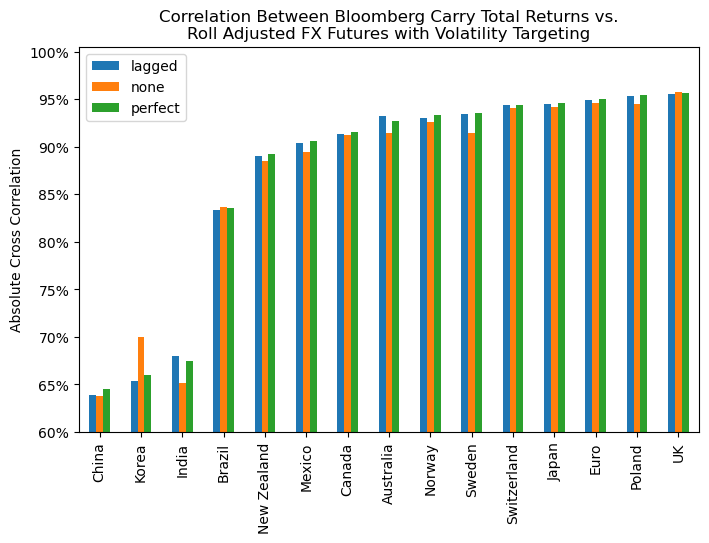

In [13]:
fig, axes = plt.subplots(figsize = (8,5))


(df_corr
    .rename(columns = {"vol_target": ""})
    .pivot(index = "country", columns = "", values = "future")
    .abs()
    .sort_values("perfect")
    .rename(columns = RENAMER)
    .plot(
        ax     = axes,
        kind   = "bar",
        ylim   = 0.6,
        ylabel = "Absolute Cross Correlation",
        xlabel = "",
        title  = "Correlation Between Bloomberg Carry Total Returns vs.\nRoll Adjusted FX Futures with Volatility Targeting"))

axes.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))

In [14]:
df_date_counter = (df_rtn
    .dropna()
    .loc[lambda x: x.vol_target == "none"]
    [["date", "country", "asset_type"]]
    .groupby(["country", "asset_type"])
    .agg("count")
    .reset_index())

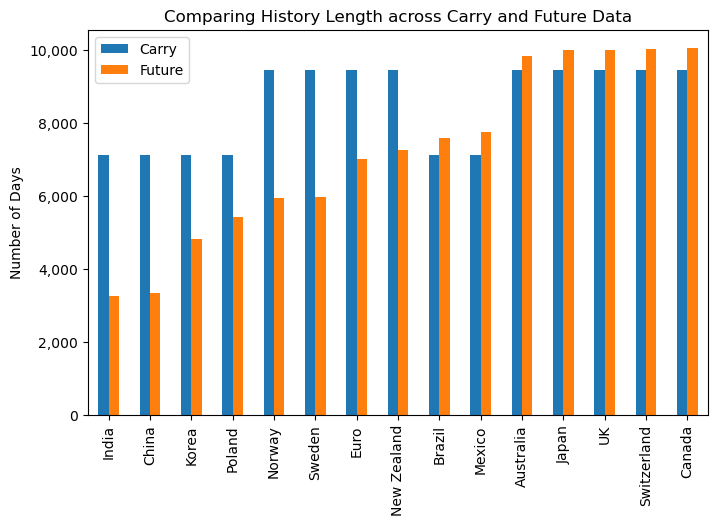

In [15]:
fig, axes = plt.subplots(figsize = (8,5))

(df_date_counter
    .rename(columns = {"asset_type": ""})
    .pivot(index = "country", columns = "", values = "date")
    .sort_values(["future", "carry"])
    .rename(columns = RENAMER)
    .plot(
        ylabel = "Number of Days",
        ax     = axes,
        kind   = "bar",
        xlabel = "",
        title  = "Comparing History Length across Carry and Future Data"))

axes.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))

In [16]:
df_date_tmp = (df_date_counter
    .pivot(index = "country", columns = "asset_type", values = "date")
    .assign(days_spread = lambda x: (x.carry - x.future).abs()))

In [17]:
df_corr_tmp = (df_corr
    .loc[lambda x: x.vol_target == "none"]
    .assign(tmp = lambda x: 1 - abs(x.future)))

df_corr_tmp = (df_corr
    .loc[lambda x: x.variable == "px_rtn"]
    .assign(tmp = lambda x: 1 - abs(x.future)))

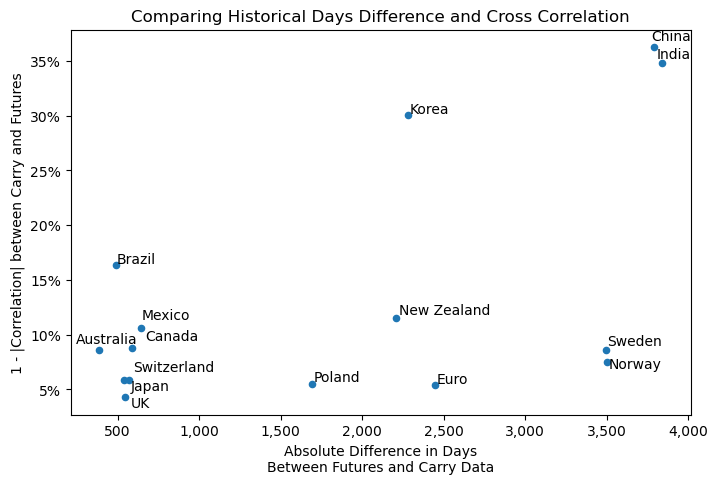

In [18]:
df_plot = df_date_tmp.merge(df_corr_tmp, how="inner", on="country")

fig, axes = plt.subplots(figsize=(8, 5))

df_plot.plot(
    kind   = "scatter",
    x      = "days_spread",
    y      = "tmp",
    ax     = axes,
    title  = "Comparing Historical Days Difference and Cross Correlation",
    ylabel = "1 - |Correlation| between Carry and Futures",
    xlabel = "Absolute Difference in Days\nBetween Futures and Carry Data")

texts = [
    axes.annotate(
        row["country"],
        (row["days_spread"], row["tmp"])
    )
    for _, row in df_plot.iterrows()
]

adjust_text(texts, ax=axes)
axes.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))
axes.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.show()

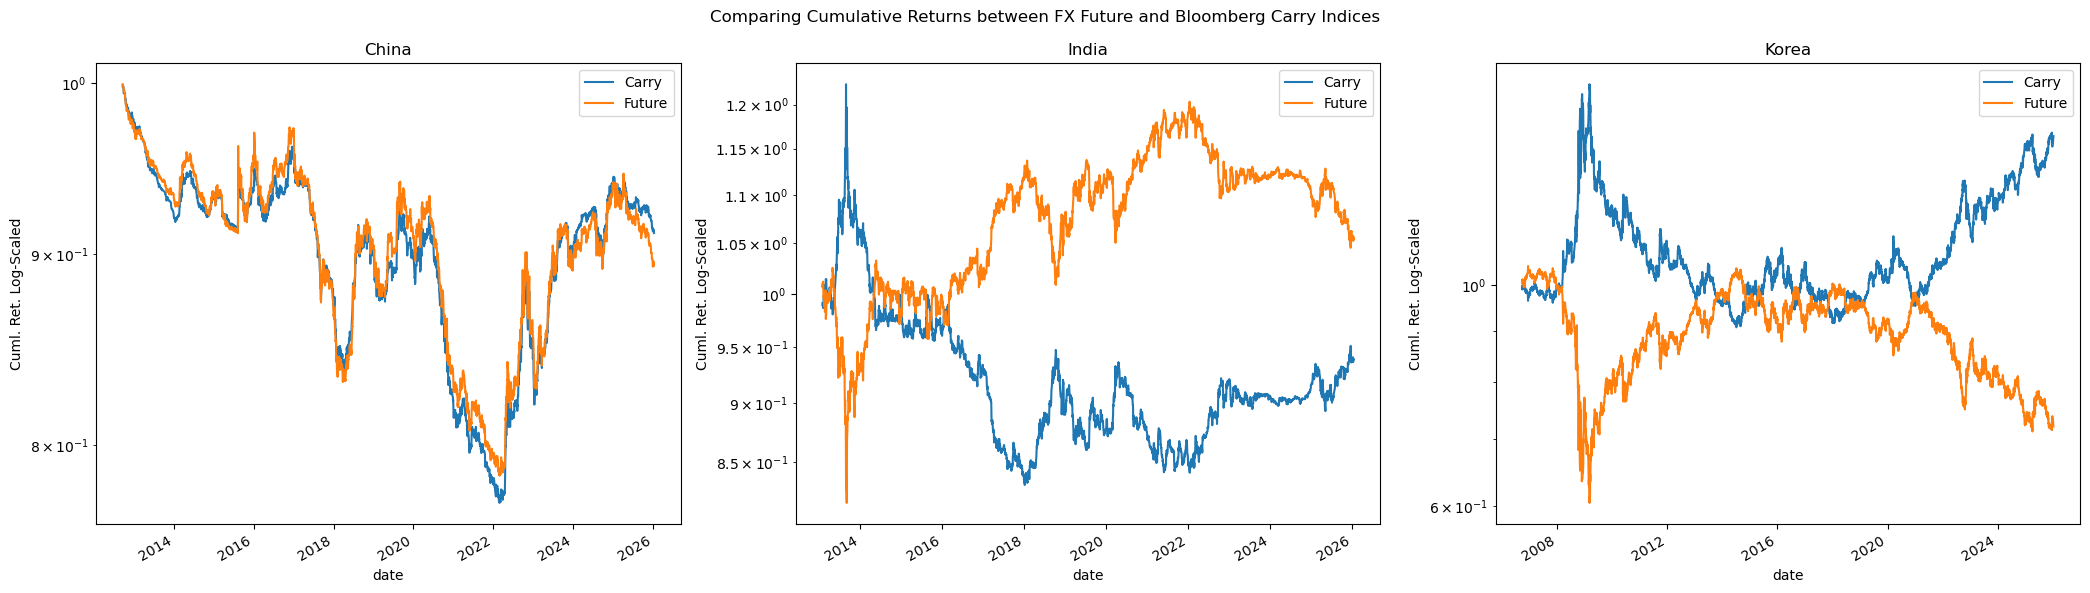

In [19]:
df_tmp = (df_rtn
    .loc[lambda x: x.country.isin(["China", "India", "Korea"])])

groups = df_tmp.country.drop_duplicates().sort_values().to_list()
fig, axes = plt.subplots(ncols = len(groups), figsize = (len(groups) * 7, 6))

for group, ax in zip(groups, axes.flatten()): 

    (df_tmp
        .loc[lambda x: x.country == group]
        .loc[lambda x: x.vol_target == "none"]
        .rename(columns = {"asset_type": ""})
        .pivot(index = "date", columns = "", values = "fx_rtn")
        .rename(columns = RENAMER)
        .dropna()
        .apply(lambda x: np.cumprod(1 + x))
        .plot(
            title  = group,
            ax     = ax,
            logy   = True,
            ylabel = "Cuml. Ret. Log-Scaled"))
    
fig.suptitle("Comparing Cumulative Returns between FX Future and Bloomberg Carry Indices")
plt.tight_layout()